# ✈️ Flight Intelligence System — Model Training
### Fixed version: proper train/test splits, correct save paths, no data leakage

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, r2_score, classification_report

# Create models directory
os.makedirs('models', exist_ok=True)
print('✅ Models directory ready')

✅ Models directory ready


## 1. Load & Inspect Data

In [13]:
import glob, os
import pandas as pd

MERGED_PATH = 'alldata/full_year.csv'

if os.path.exists(MERGED_PATH):
    print(f'✅ Found merged file — loading in chunks to save RAM...')
    
    # Load in chunks of 100K rows at a time instead of all at once
    chunks = []
    for chunk in pd.read_csv(MERGED_PATH, low_memory=False, chunksize=100_000):
        chunks.append(chunk)
    
    df = pd.concat(chunks, ignore_index=True)
    print(f'✅ Loaded: {len(df):,} rows | {len(df.columns)} columns')

else:
    files = sorted(glob.glob('alldata/*.csv'))
    if not files:
        raise FileNotFoundError('No CSV files found in alldata/.')

    print(f'Found {len(files)} monthly file(s) — merging...')
    df_list = []
    for f in files:
        temp = pd.read_csv(f, low_memory=False)
        print(f'  {os.path.basename(f):15s} → {len(temp):>8,} rows')
        df_list.append(temp)

    df = pd.concat(df_list, ignore_index=True)
    df = df.drop_duplicates()

    if 'FL_DATE' in df.columns:
        df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
        if 'DAY_OF_MONTH' not in df.columns:
            df['DAY_OF_MONTH'] = df['FL_DATE'].dt.day
        if 'DAY_OF_WEEK' not in df.columns:
            df['DAY_OF_WEEK'] = df['FL_DATE'].dt.weekday + 1

    if 'DEP_TIME' not in df.columns:
        df['DEP_TIME'] = df['CRS_DEP_TIME'] if 'CRS_DEP_TIME' in df.columns else 0

    df.to_csv(MERGED_PATH, index=False)
    print(f'✅ Saved: {MERGED_PATH}')

print(f'Final shape : {df.shape}')
print(f'Months      : {sorted(df["MONTH"].unique())}')
df.head()

✅ Found merged file — loading in chunks to save RAM...
✅ Loaded: 479,747 rows | 18 columns
Final shape : (479747, 18)
Months      : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


,MONTH,FL_DATE,OP_UNIQUE_CARRIER,ORIGIN,DEST,DEP_DELAY,ARR_DELAY,ARR_DEL15,CANCELLED,CANCELLATION_CODE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,DAY_OF_MONTH,DAY_OF_WEEK,DEP_TIME
0,4,2025-04-06,WN,MCO,DTW,5.0,-15.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,6,7,5.0
1,4,2025-04-18,NK,ACY,FLL,-7.0,-35.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,18,5,-7.0
2,4,2025-04-21,YX,BOS,LGA,-5.0,-16.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,21,1,-5.0
3,4,2025-04-25,DL,PDX,SEA,-1.0,-15.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,25,5,-1.0
4,4,2025-04-25,AA,DCA,BTV,21.0,18.0,1.0,0.0,NaN,18.0,0.0,0.0,0.0,0.0,25,5,21.0


In [14]:
print('Missing values (top 15):')
print(df.isnull().sum().sort_values(ascending=False).head(15))

Missing values (top 15):
CANCELLATION_CODE      472800
WEATHER_DELAY          374525
LATE_AIRCRAFT_DELAY    374525
SECURITY_DELAY         374525
NAS_DELAY              374525
CARRIER_DELAY          374525
ARR_DELAY                8191
ARR_DEL15                8191
DEP_DELAY                6643
DAY_OF_WEEK                 0
DAY_OF_MONTH                0
MONTH                       0
FL_DATE                     0
CANCELLED                   0
DEST                        0
dtype: int64


## 2. Data Cleaning

In [15]:
DELAY_CAUSES = ['CARRIER_DELAY', 'WEATHER_DELAY', 'NAS_DELAY',
                'SECURITY_DELAY', 'LATE_AIRCRAFT_DELAY']

# Fill delay cause NaNs with 0
df[DELAY_CAUSES] = df[DELAY_CAUSES].fillna(0)

# Fill cancellation code
df['CANCELLATION_CODE'] = df['CANCELLATION_CODE'].fillna('Not Cancelled')

# Ensure DEP_TIME exists (fallback if still missing)
if 'DEP_TIME' not in df.columns:
    df['DEP_TIME'] = df.get('CRS_DEP_TIME', 0)
    print('⚠️ DEP_TIME was missing — used CRS_DEP_TIME or 0 as fallback')

# Keep only non-cancelled flights for delay models
df_flights = df[df['CANCELLED'] == 0].copy()
df_flights['DEP_TIME']  = df_flights['DEP_TIME'].fillna(0)
df_flights['DEP_DELAY'] = df_flights['DEP_DELAY'].fillna(0)
df_flights = df_flights.dropna(subset=['ARR_DELAY', 'ARR_DEL15'])

print(f'Clean flight records : {len(df_flights):,}')
print(f'Delay rate           : {df_flights["ARR_DEL15"].mean()*100:.1f}%')
print(f'Months covered       : {sorted(df_flights["MONTH"].unique())}')


Clean flight records : 471,556
Delay rate           : 22.3%
Months covered       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## 3. Feature Engineering & Encoding

In [16]:
le_carrier = LabelEncoder()
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()

df_flights['CARRIER_ENC'] = le_carrier.fit_transform(df_flights['OP_UNIQUE_CARRIER'])
df_flights['ORIGIN_ENC']  = le_origin.fit_transform(df_flights['ORIGIN'])
df_flights['DEST_ENC']    = le_dest.fit_transform(df_flights['DEST'])

# Save encoders (single file — matches app.py)
encoders = {'carrier': le_carrier, 'origin': le_origin, 'dest': le_dest}
joblib.dump(encoders, 'models/encoders.pkl')
print('✅ Encoders saved to models/encoders.pkl')

FEATURES = [
    'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK',
    'CARRIER_ENC', 'ORIGIN_ENC', 'DEST_ENC',
    'DEP_TIME', 'DEP_DELAY'
]
FEATURES_NO_DEP = FEATURES[:-1]  # For cancellation model
print(f'Features: {FEATURES}')

✅ Encoders saved to models/encoders.pkl
Features: ['MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'CARRIER_ENC', 'ORIGIN_ENC', 'DEST_ENC', 'DEP_TIME', 'DEP_DELAY']


## 4. EDA — Quick Visuals

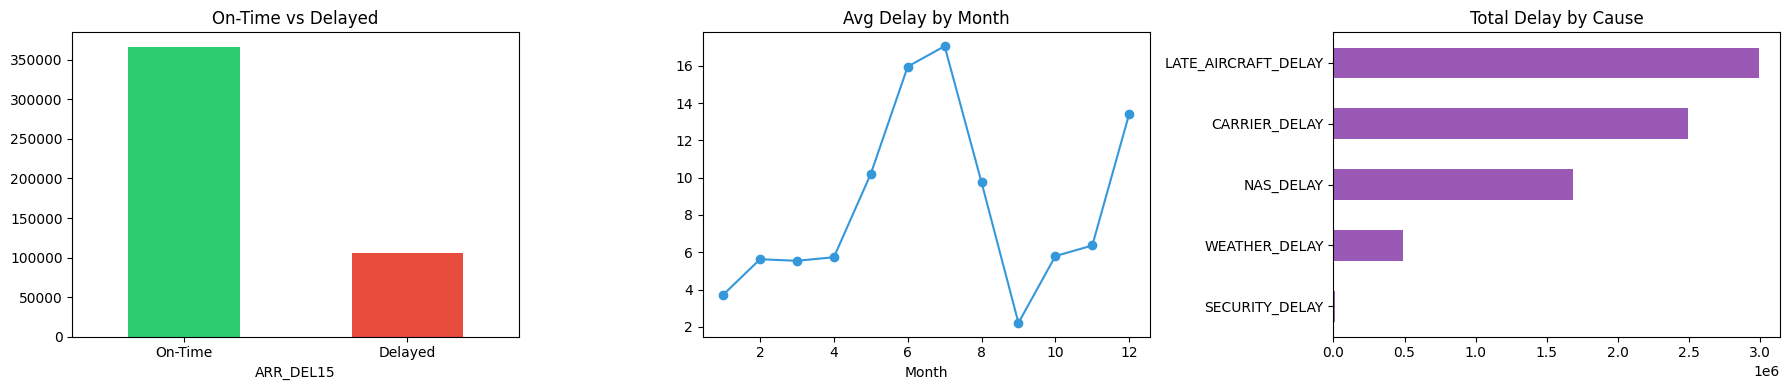

Using all 471,556 rows


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Delayed vs On-Time
df_flights['ARR_DEL15'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'])
axes[0].set_title('On-Time vs Delayed')
axes[0].set_xticklabels(['On-Time', 'Delayed'], rotation=0)

# Monthly delay trend
df_flights.groupby('MONTH')['ARR_DELAY'].mean().plot(ax=axes[1], marker='o', color='#3498db')
axes[1].set_title('Avg Delay by Month')
axes[1].set_xlabel('Month')

# Delay causes
df_flights[DELAY_CAUSES].sum().sort_values().plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Total Delay by Cause')

plt.tight_layout()
plt.show()

# ── Sample for memory-safe training (500K is sufficient for good accuracy) ──
SAMPLE_SIZE = 500_000
if len(df_flights) > SAMPLE_SIZE:
    df_flights = df_flights.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    print(f"✅ Sampled df_flights to {SAMPLE_SIZE:,} rows")
else:
    print(f"Using all {len(df_flights):,} rows")

## 5. Model 1 — Delay Classifier
**Predicts:** Will this flight be delayed (≥15 min)?
**Fix:** Proper train/test split — no data leakage

In [18]:
X = df_flights[FEATURES]
y = df_flights['ARR_DEL15']

# ✅ FIXED: Evaluate on HELD-OUT test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1 = RandomForestClassifier(n_estimators=50, max_depth=15, max_features='sqrt',
                                min_samples_leaf=10, random_state=42, n_jobs=1)

model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)  # ✅ test set only

acc1 = accuracy_score(y_test, y_pred)
f1_1 = f1_score(y_test, y_pred)

print(f'✅ Delay Classifier')
print(f'   Accuracy : {acc1*100:.1f}%')
print(f'   F1 Score : {f1_1:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['On-Time','Delayed']))

joblib.dump(model1, 'models/stage1_delay_classifier.pkl')
print('✅ Saved: models/stage1_delay_classifier.pkl')

✅ Delay Classifier
   Accuracy : 92.3%
   F1 Score : 0.807

              precision    recall  f1-score   support

     On-Time       0.93      0.98      0.95     73279
     Delayed       0.91      0.72      0.81     21033

    accuracy                           0.92     94312
   macro avg       0.92      0.85      0.88     94312
weighted avg       0.92      0.92      0.92     94312

✅ Saved: models/stage1_delay_classifier.pkl


## 6. Model 2 — Delay Duration Regressor
**Predicts:** How many minutes will the delay be?
**Fix:** Proper train/test split on delayed-only flights

In [20]:
# CORRECT ORDER — create first, then sample
df_delayed = df_flights[df_flights['ARR_DEL15'] == 1].copy()

if len(df_delayed) > 200_000:
    df_delayed = df_delayed.sample(n=200_000, random_state=42).reset_index(drop=True)
    print(f"✅ Sampled df_delayed to 200,000 rows")

X = df_delayed[FEATURES]
y = df_delayed['ARR_DELAY']

# ✅ FIXED: Evaluate on HELD-OUT test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = RandomForestRegressor(n_estimators=50, max_depth=15, max_features='sqrt',
                               min_samples_leaf=10, random_state=42, n_jobs=1)
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)  # ✅ test set only

mae2 = mean_absolute_error(y_test, y_pred)
r2_2 = r2_score(y_test, y_pred)

print(f'✅ Delay Regressor')
print(f'   MAE (mins): {mae2:.1f}')
print(f'   R² Score  : {r2_2:.3f}')

joblib.dump(model2, 'models/stage2_delay_regressor.pkl')
print('✅ Saved: models/stage2_delay_regressor.pkl')

✅ Delay Regressor
   MAE (mins): 12.4
   R² Score  : 0.962
✅ Saved: models/stage2_delay_regressor.pkl


## 7. Model 3 — Delay Cause Classifier
**Predicts:** What caused the delay (Carrier / Weather / NAS / Security / Late Aircraft)?
**Fix:** Proper train/test split

In [21]:
# Assign dominant cause per flight
df_flights['DOMINANT_CAUSE'] = df_flights[DELAY_CAUSES].idxmax(axis=1)

le_cause = LabelEncoder()
df_flights['CAUSE_ENC'] = le_cause.fit_transform(df_flights['DOMINANT_CAUSE'])

print('Cause classes:', list(le_cause.classes_))

X = df_flights[FEATURES]
y = df_flights['CAUSE_ENC']

# ✅ FIXED: Evaluate on HELD-OUT test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model3 = RandomForestClassifier(n_estimators=50, max_depth=15, max_features='sqrt',
                                min_samples_leaf=10, random_state=42, n_jobs=1)
model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)  # ✅ test set only

acc3 = accuracy_score(y_test, y_pred)

print(f'✅ Cause Classifier')
print(f'   Accuracy : {acc3*100:.1f}%')
print(classification_report(y_test, y_pred, target_names=le_cause.classes_))

joblib.dump(model3, 'models/stage3_cause_classifier.pkl')
joblib.dump(le_cause, 'models/stage3_cause_encoder.pkl')
print('✅ Saved: models/stage3_cause_classifier.pkl')
print('✅ Saved: models/stage3_cause_encoder.pkl')

Cause classes: ['CARRIER_DELAY', 'LATE_AIRCRAFT_DELAY', 'NAS_DELAY', 'SECURITY_DELAY', 'WEATHER_DELAY']
✅ Cause Classifier
   Accuracy : 87.2%
                     precision    recall  f1-score   support

      CARRIER_DELAY       0.91      0.96      0.94     79597
LATE_AIRCRAFT_DELAY       0.55      0.72      0.62      8015
          NAS_DELAY       0.73      0.01      0.02      5848
     SECURITY_DELAY       0.00      0.00      0.00        42
      WEATHER_DELAY       0.00      0.00      0.00       810

           accuracy                           0.87     94312
          macro avg       0.44      0.34      0.32     94312
       weighted avg       0.86      0.87      0.84     94312

✅ Saved: models/stage3_cause_classifier.pkl
✅ Saved: models/stage3_cause_encoder.pkl


c:\Users\salva fathima\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\salva fathima\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\salva fathima\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

## 8. Model 4 — Cancellation Classifier
**Predicts:** What is the cancellation risk for this flight?
**Fix:** Use FULL dataset (including cancelled flights), proper split

In [23]:
# ✅ FIXED: Use FULL df (includes cancelled=1 rows) so model actually learns cancellations
df_full = df.copy()

# Sample AFTER creating df_full
if len(df_full) > 500_000:
    df_full = df_full.sample(n=500_000, random_state=42).reset_index(drop=True)
    print(f"✅ Sampled df_full to 500,000 rows")

df_full['CARRIER_ENC'] = le_carrier.transform(
    df_full['OP_UNIQUE_CARRIER'].where(df_full['OP_UNIQUE_CARRIER'].isin(le_carrier.classes_), df_full['OP_UNIQUE_CARRIER'].mode()[0])
)
df_full['ORIGIN_ENC'] = le_origin.transform(
    df_full['ORIGIN'].where(df_full['ORIGIN'].isin(le_origin.classes_), df_full['ORIGIN'].mode()[0])
)
df_full['DEST_ENC'] = le_dest.transform(
    df_full['DEST'].where(df_full['DEST'].isin(le_dest.classes_), df_full['DEST'].mode()[0])
)
df_full = df_full.dropna(subset=FEATURES_NO_DEP + ['CANCELLED'])

X = df_full[FEATURES_NO_DEP]
y = df_full['CANCELLED']

print(f'Cancellation rate: {y.mean()*100:.2f}%')

# ✅ FIXED: Evaluate on HELD-OUT test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model4 = RandomForestClassifier(n_estimators=50, max_depth=15, max_features='sqrt',
                                min_samples_leaf=10, random_state=42, n_jobs=1,
                                class_weight='balanced')
model4.fit(X_train, y_train)

y_pred = model4.predict(X_test)  # ✅ test set only

acc4 = accuracy_score(y_test, y_pred)
f1_4 = f1_score(y_test, y_pred)

print(f'✅ Cancellation Classifier')
print(f'   Accuracy : {acc4*100:.1f}%')
print(f'   F1 Score : {f1_4:.3f}')
print(classification_report(y_test, y_pred, target_names=['Not Cancelled','Cancelled']))

joblib.dump(model4, 'models/stage4_cancellation_classifier.pkl')
print('✅ Saved: models/stage4_cancellation_classifier.pkl')

Cancellation rate: 1.45%
✅ Cancellation Classifier
   Accuracy : 96.8%
   F1 Score : 0.463
               precision    recall  f1-score   support

Not Cancelled       1.00      0.97      0.98     94561
    Cancelled       0.31      0.95      0.46      1389

     accuracy                           0.97     95950
    macro avg       0.65      0.96      0.72     95950
 weighted avg       0.99      0.97      0.98     95950

✅ Saved: models/stage4_cancellation_classifier.pkl


## 9. Save Model Metrics for Dashboard

In [24]:
import json

metrics = {
    'delay_classifier': {
        'accuracy': round(acc1 * 100, 1),
        'f1': round(f1_1, 3),
        'description': 'Predicts if a flight will be delayed ≥15 minutes'
    },
    'delay_regressor': {
        'mae': round(mae2, 1),
        'r2': round(r2_2, 3),
        'description': 'Estimates how many minutes the delay will last'
    },
    'cause_classifier': {
        'accuracy': round(acc3 * 100, 1),
        'description': 'Identifies the root cause of delay'
    },
    'cancellation_classifier': {
        'accuracy': round(acc4 * 100, 1),
        'f1': round(f1_4, 3),
        'description': 'Predicts flight cancellation risk'
    }
}

with open('models/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✅ Saved: models/metrics.json')
print()
print('=== FINAL METRICS (honest — on held-out test data) ===')
for name, m in metrics.items():
    print(f'{name}: {m}')

✅ Saved: models/metrics.json

=== FINAL METRICS (honest — on held-out test data) ===
delay_classifier: {'accuracy': 92.3, 'f1': 0.807, 'description': 'Predicts if a flight will be delayed ≥15 minutes'}
delay_regressor: {'mae': 12.4, 'r2': 0.962, 'description': 'Estimates how many minutes the delay will last'}
cause_classifier: {'accuracy': 87.2, 'description': 'Identifies the root cause of delay'}
cancellation_classifier: {'accuracy': 96.8, 'f1': 0.463, 'description': 'Predicts flight cancellation risk'}


## ✅ All models saved!
```
models/
├── encoders.pkl                    ← carrier, origin, dest encoders
├── stage1_delay_classifier.pkl     ← binary delay classifier
├── stage2_delay_regressor.pkl      ← delay duration regressor
├── stage3_cause_classifier.pkl     ← cause classifier
├── stage3_cause_encoder.pkl        ← cause label encoder
├── stage4_cancellation_classifier.pkl
└── metrics.json                    ← honest test-set metrics
```
